# Feed activity

Plots of how active the feed has been in some given time period.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from datetime import datetime, timedelta, date
from pathlib import Path

In [3]:
datadir = Path("../../_backups/250619_parquet")

In [ ]:
posts = pd.read_parquet(datadir / "post.parquet")
accounts = pd.read_parquet(datadir / "account.parquet")
activitylog = pd.read_parquet(datadir / "activitylog.parquet")

## Fix type issues

As pgdump isn't very consistent with .csv 'standards'

In [57]:
def convert_to_boolean(dataframe, columns):
    for col in columns:
        dataframe[col] = np.where(dataframe[col] == "t", True, False)
    return dataframe


print("Working on posts...")
bool_columns = {col: bool for col in posts.columns if "feed_" in col or col == "hidden"}
posts = convert_to_boolean(posts, bool_columns)
posts["indexed_at"] = pd.to_datetime(posts["indexed_at"], format="mixed")

print("Working on accounts...")
bool_columns = {col: bool for col in accounts.columns if "is_" in col}
accounts = convert_to_boolean(accounts, bool_columns)
accounts["indexed_at"] = pd.to_datetime(accounts["indexed_at"], format="mixed")

print("Working on activitylog...")
bool_columns = dict(request_is_scrolled=bool)
activitylog = convert_to_boolean(activitylog, bool_columns)
activitylog["request_dt"] = pd.to_datetime(activitylog["request_dt"], format="mixed")

Working on posts...
Working on accounts...
Working on activitylog...


## Pre-process into valid posts only

In [58]:
print("Posts before:", len(posts))
posts = posts.loc[np.isin(posts['author'], accounts.query("is_valid == True")["did"])].reset_index(drop=True)
print("Posts after:", len(posts))

# Also, join handles into posts
posts = posts.merge(accounts[["did", "handle"]], left_on="author", right_on="did", how="left")

Posts before: 1146618
Posts after: 1011296


In [59]:
posts['indexed_at'].loc[0]

Timestamp('2023-07-07 22:02:31')

In [60]:
astro_feed_posts = posts.loc[posts['feed_astro']].reset_index(drop=True)

## Posts over time

In [99]:
aggregator = dict(
    feed_astro="sum", feed_exoplanets="sum", feed_astrophotos="sum", author="nunique"
)

by_day = (
    astro_feed_posts.groupby(by=astro_feed_posts["indexed_at"].dt.date)
    .aggregate(aggregator)
    .reset_index()
)
by_day_of_the_week = (
    astro_feed_posts.groupby(by=astro_feed_posts["indexed_at"].dt.strftime("%w"))
    .aggregate(aggregator)
    .reset_index()
)
by_week = (
    astro_feed_posts.groupby(by=astro_feed_posts["indexed_at"].dt.strftime("%Y%W"))
    .aggregate(aggregator)
    .reset_index()
)
by_month = (
    astro_feed_posts.groupby(by=astro_feed_posts["indexed_at"].dt.strftime("%Y%m"))
    .aggregate(aggregator)
    .reset_index()
)

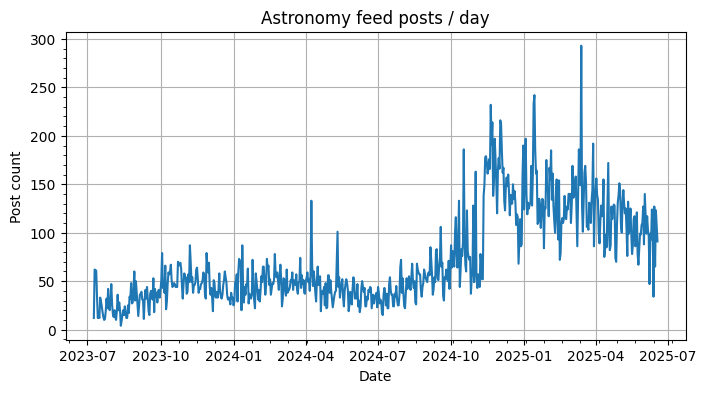

In [100]:
days_to_plot = by_day.iloc[:-1]  # Exclude today

fig, ax = plt.subplots(figsize=(8, 4), facecolor="w")
ax.plot(days_to_plot['indexed_at'], days_to_plot['feed_astro'])
ax.set(title="Astronomy feed posts / day", xlabel="Date", ylabel="Post count")
ax.grid()
ax.minorticks_on()

fig.savefig("output/posts_per_day.png", bbox_inches="tight")

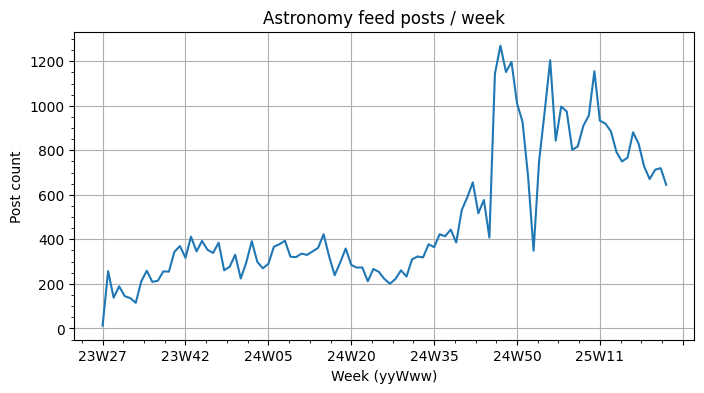

In [101]:
days_to_plot = by_week.iloc[:-1]  # Exclude today

fig, ax = plt.subplots(figsize=(8, 4), facecolor="w")
weeks = [f"{x[2:4]}W{x[4:]}" for x in days_to_plot['indexed_at']]
ax.plot(weeks, days_to_plot['feed_astro'])
ax.set(title="Astronomy feed posts / week", xlabel="Week (yyWww)", ylabel="Post count")
ax.grid()
ax.xaxis.set_major_locator(plt.MaxNLocator(8))
ax.minorticks_on()

fig.savefig("output/posts_per_week.png", bbox_inches="tight")

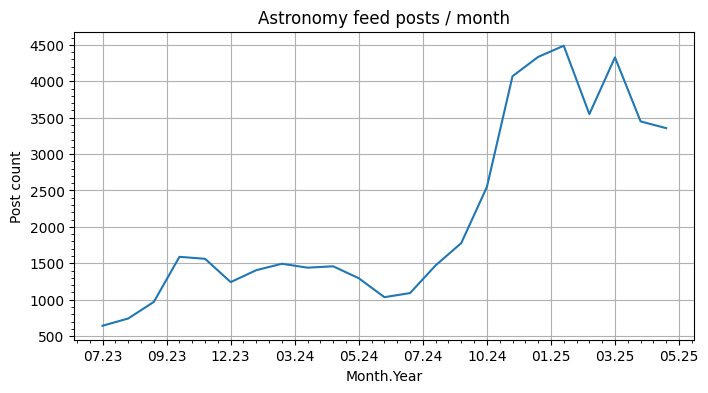

In [102]:
days_to_plot = by_month.iloc[:-1]  # Exclude today

fig, ax = plt.subplots(figsize=(8, 4), facecolor="w")
months = [f"{x[4:]}.{x[2:4]}" for x in days_to_plot['indexed_at']]
ax.plot(months, days_to_plot['feed_astro'])
ax.set(title="Astronomy feed posts / month", xlabel="Month.Year", ylabel="Post count")
ax.grid()
ax.minorticks_on()
ax.xaxis.set_major_locator(plt.MaxNLocator(10))

fig.savefig("output/posts_per_month.png", bbox_inches="tight")

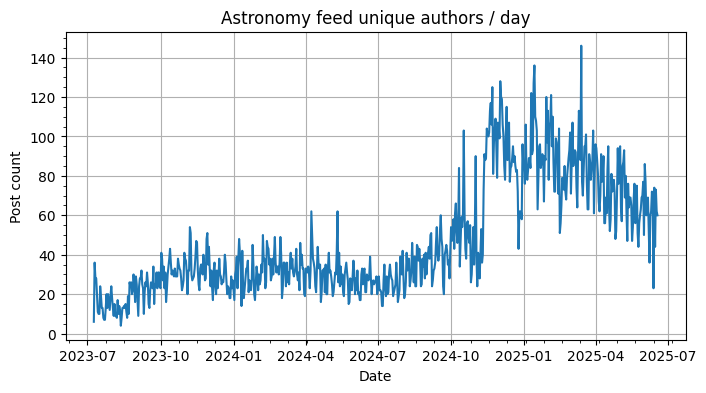

In [103]:
days_to_plot = by_day.iloc[:-1]  # Exclude today

fig, ax = plt.subplots(figsize=(8, 4), facecolor="w")
# ax.plot(days_to_plot['indexed_at'], days_to_plot['feed_astro'])
ax.plot(days_to_plot['indexed_at'], days_to_plot['author'])
ax.set(title="Astronomy feed unique authors / day", xlabel="Date", ylabel="Post count")
ax.grid()
ax.minorticks_on()

fig.savefig("output/authors_per_day.png", bbox_inches="tight")

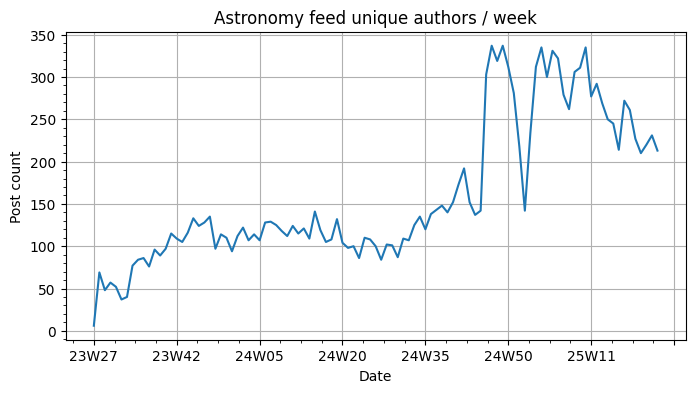

In [104]:
days_to_plot = by_week.iloc[:-1]  # Exclude today

fig, ax = plt.subplots(figsize=(8, 4), facecolor="w")
weeks = [f"{x[2:4]}W{x[4:]}" for x in days_to_plot['indexed_at']]
ax.plot(weeks, days_to_plot['author'])
ax.set(title="Astronomy feed unique authors / week", xlabel="Date", ylabel="Post count")
ax.grid()
ax.minorticks_on()
ax.xaxis.set_major_locator(plt.MaxNLocator(8))

fig.savefig("output/authors_per_week.png", bbox_inches="tight")

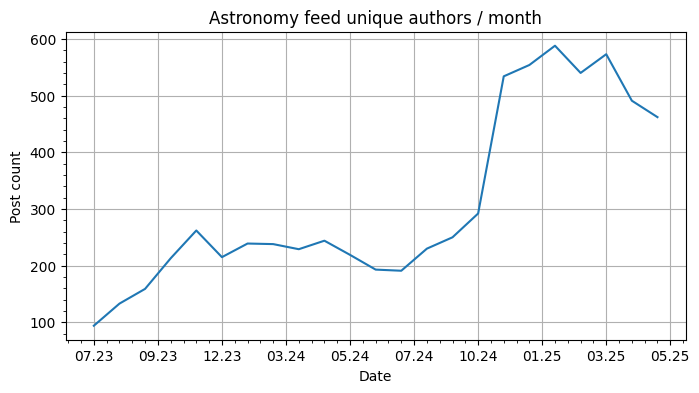

In [105]:
days_to_plot = by_month.iloc[:-1]  # Exclude today

fig, ax = plt.subplots(figsize=(8, 4), facecolor="w")
months = [f"{x[4:]}.{x[2:4]}" for x in days_to_plot['indexed_at']]
ax.plot(months, days_to_plot['author'])
ax.set(title="Astronomy feed unique authors / month", xlabel="Date", ylabel="Post count")
ax.grid()
ax.minorticks_on()
ax.xaxis.set_major_locator(plt.MaxNLocator(10))

fig.savefig("output/authors_per_month.png", bbox_inches="tight")

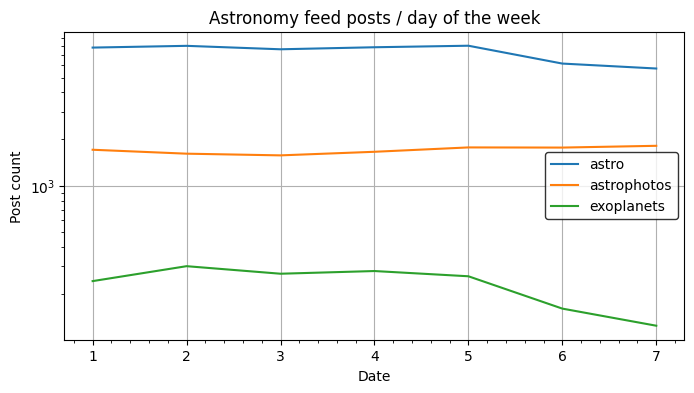

In [106]:
days_to_plot = by_day_of_the_week.copy()
days_to_plot['indexed_at'] = (days_to_plot['indexed_at'].astype(int) + 6) % 7 + 1
days_to_plot = days_to_plot.sort_values("indexed_at")

fig, ax = plt.subplots(figsize=(8, 4), facecolor="w")
# ax.plot(days_to_plot['indexed_at'], days_to_plot['feed_astro'])
ax.plot(days_to_plot['indexed_at'], days_to_plot['feed_astro'], label="astro")
ax.plot(days_to_plot['indexed_at'], days_to_plot['feed_astrophotos'], label="astrophotos")
ax.plot(days_to_plot['indexed_at'], days_to_plot['feed_exoplanets'], label="exoplanets")
ax.set(title="Astronomy feed posts / day of the week", xlabel="Date", ylabel="Post count", yscale="log")
ax.grid()
ax.minorticks_on()
ax.legend(edgecolor="k")

fig.savefig("output/posts_per_day_of_the_week.png", bbox_inches="tight")

## Authors over time

In [73]:
valid_accounts = accounts.query("is_valid == 1").reset_index(drop=True)

In [74]:
aggregator = dict(handle="count")

# So that we don't have missing days
start_day = valid_accounts["indexed_at"].dt.date.min()
n_days = (datetime.today().date() - start_day).days
date_list = [start_day + timedelta(days=x) for x in range(n_days + 1)]

signups_per_day = (
    valid_accounts.groupby(by=valid_accounts["indexed_at"].dt.date)
    .aggregate(aggregator)
    .rename(columns=dict(handle="signups"))
    .reset_index()
)

signups_per_day_all_days = (
    pd.DataFrame.from_dict({"indexed_at": date_list, "signups": 0})
    .set_index("indexed_at"))
signups_per_day_all_days.update(signups_per_day.set_index("indexed_at"))
signups_per_day = signups_per_day_all_days.reset_index()

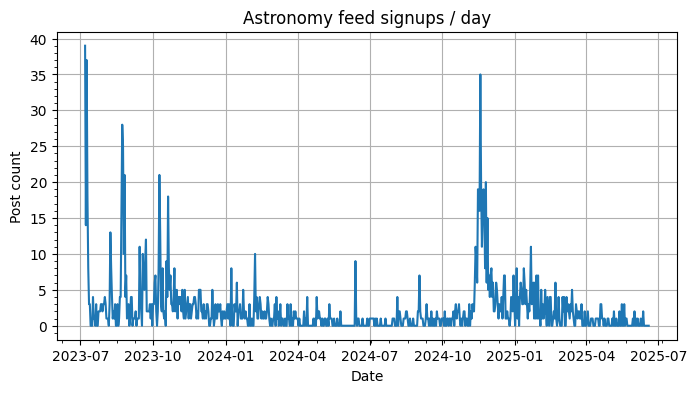

In [75]:
days_to_plot = by_day.iloc[:-1]  # Exclude today

fig, ax = plt.subplots(figsize=(8, 4), facecolor="w")
ax.plot(signups_per_day['indexed_at'], signups_per_day['signups'])
ax.set(title="Astronomy feed signups / day", xlabel="Date", ylabel="Post count")
ax.grid()
ax.minorticks_on()

fig.savefig("output/signups_per_day.png", bbox_inches="tight")

## Requests over time

In [77]:
requests_users = activitylog.loc[activitylog['request_user_did'] != 'Unknown']
requests_scrolled = requests_users.loc[requests_users["request_is_scrolled"]].reset_index(
    drop=True
)

In [81]:
aggregator = dict(
    total=pd.NamedAgg("request_user_did", "count"),
    scrolled=pd.NamedAgg("request_is_scrolled", "sum"),
    unique_users=pd.NamedAgg("request_user_did", "nunique"),
)

by_day = (
    requests_users.groupby(by=requests_users["request_dt"].dt.date)
    .aggregate(**aggregator)
    .reset_index()
)
by_day_of_the_week = (
    requests_users.groupby(by=requests_users["request_dt"].dt.strftime("%w"))
    .aggregate(**aggregator)
    .reset_index()
)
by_week = (
    requests_users.groupby(by=requests_users["request_dt"].dt.strftime("%Y%W"))
    .aggregate(**aggregator)
    .reset_index()
)
by_month = (
    requests_users.groupby(by=requests_users["request_dt"].dt.strftime("%Y%m"))
    .aggregate(**aggregator)
    .reset_index()
)

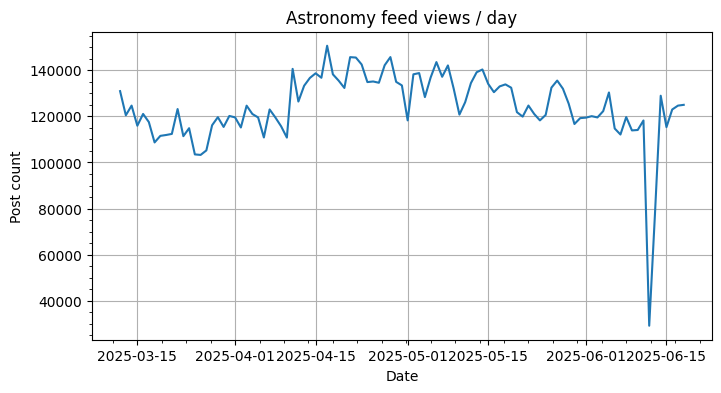

In [88]:
days_to_plot = by_day.iloc[1:-1]  # Exclude today + first day

fig, ax = plt.subplots(figsize=(8, 4), facecolor="w")
ax.plot(days_to_plot['request_dt'], days_to_plot['total'])
ax.set(title="Astronomy feed views / day", xlabel="Date", ylabel="Post count")
ax.grid()
ax.minorticks_on()

fig.savefig("output/views_per_day.png", bbox_inches="tight")

## Scrolls over time

In [95]:
aggregator = dict(
    total=pd.NamedAgg("request_user_did", "count"),
    scrolled=pd.NamedAgg("request_is_scrolled", "sum"),
    unique_users=pd.NamedAgg("request_user_did", "nunique"),
)

by_day = (
    requests_scrolled.groupby(by=requests_scrolled["request_dt"].dt.date)
    .aggregate(**aggregator)
    .reset_index()
)
by_day_of_the_week = (
    requests_scrolled.groupby(by=requests_scrolled["request_dt"].dt.strftime("%w"))
    .aggregate(**aggregator)
    .reset_index()
)
by_week = (
    requests_scrolled.groupby(by=requests_scrolled["request_dt"].dt.strftime("%Y%W"))
    .aggregate(**aggregator)
    .reset_index()
)
by_month = (
    requests_scrolled.groupby(by=requests_scrolled["request_dt"].dt.strftime("%Y%m"))
    .aggregate(**aggregator)
    .reset_index()
)

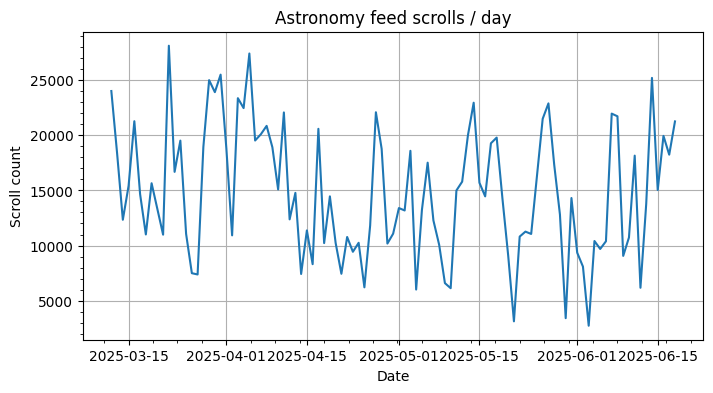

In [96]:
days_to_plot = by_day.iloc[1:-1]  # Exclude today + first day

fig, ax = plt.subplots(figsize=(8, 4), facecolor="w")
ax.plot(days_to_plot['request_dt'], days_to_plot['total'])
ax.set(title="Astronomy feed scrolls / day", xlabel="Date", ylabel="Scroll count")
ax.grid()
ax.minorticks_on()

fig.savefig("output/scrolls_per_day.png", bbox_inches="tight")

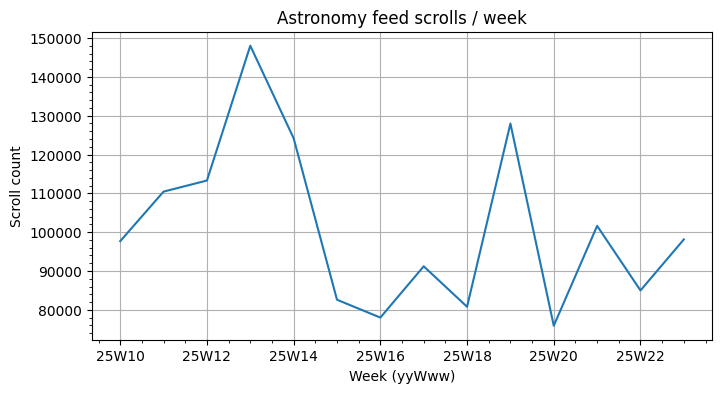

In [97]:
days_to_plot = by_week.iloc[:-1]  # Exclude today

fig, ax = plt.subplots(figsize=(8, 4), facecolor="w")
weeks = [f"{x[2:4]}W{x[4:]}" for x in days_to_plot['request_dt']]
ax.plot(weeks, days_to_plot['scrolled'])
ax.set(title="Astronomy feed scrolls / week", xlabel="Week (yyWww)", ylabel="Scroll count")
ax.grid()
ax.xaxis.set_major_locator(plt.MaxNLocator(8))
ax.minorticks_on()

fig.savefig("output/scrolls_per_week.png", bbox_inches="tight")

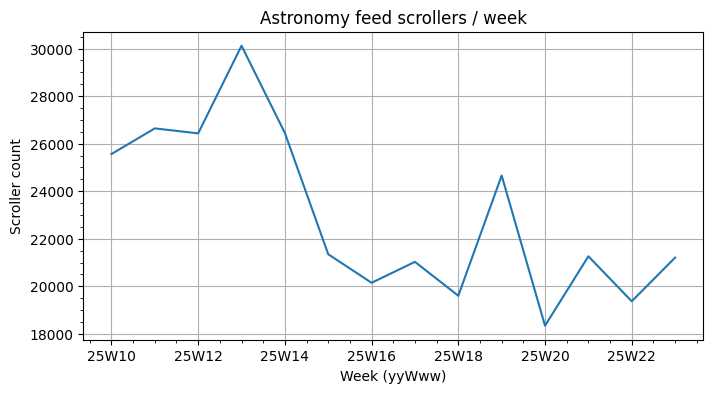

In [98]:
days_to_plot = by_week.iloc[:-1]  # Exclude today

fig, ax = plt.subplots(figsize=(8, 4), facecolor="w")
weeks = [f"{x[2:4]}W{x[4:]}" for x in days_to_plot['request_dt']]
ax.plot(weeks, days_to_plot['unique_users'])
ax.set(title="Astronomy feed scrollers / week", xlabel="Week (yyWww)", ylabel="Scroller count")
ax.grid()
ax.xaxis.set_major_locator(plt.MaxNLocator(8))
ax.minorticks_on()

fig.savefig("output/scrollers_per_week.png", bbox_inches="tight")